# *Pós-graduação em Ciência e Dados e Machine Learning*
### *Trabalho Final - Machine Learning*

**Disciplina:** Fundamentos de Machine Learning

**Professor:** André Juan Costa Vieira

**Turma:** A

**Nomes dos Integrantes:**

1-

2-

3-

### Modelos não Supervisionados

**Utilize o dataset 'wines.csv' e 'wines_splines.csv'**

Chuck Norris tem um amigo famoso no mundo da ciência de dados, seu nome é Rocky Balboa. Em uma conversa sobre alguns métodos que podem ser utilizados para criar novos vetores (_features engineering_), o Sr.Rocky propôs que fossem utilizados Splines. Completamente emocionado com a ideia, Chuck decidiu aplicar esta técnica utilizando até a oitava potência.

Ele pediu a você que fizesse um estudo comparativo utilizando o PCA. O intuito é analisar se a redução de dimensionalidade pode ser vantajosa para o dataset original e o dataset com Splines.

1- Compare a variância explicada de cada um dos datasets

2- Explique porque o PCA seria, ou não uma boa abordagem para o dataset com Splines. Ademais, discorra sobre a influência de ruídos.

3- Utilize um loop "for" e crie uma condição para que, quando a variância for maior do que 0.92, seja retornado o número de features totais, faça para ambos datasets.

4- Qual seria o método mais indicado para redução de dimensionalidade nesse caso?

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [27]:
df = pd.read_csv('../../data/trabalho_ML2/wines.csv')
df_spl = pd.read_csv('../../data/trabalho_ML2/wines_splines.csv')

print('duplicadas:', df.duplicated().sum(), df_spl.duplicated().sum())
df = df.drop_duplicates()  # mesmo criterio do trabalho de ml 1
df_spl = df_spl.drop_duplicates()

# categ e so o numero da faixa de acucar usada pra montar as splines, nao e medida do vinho
X_orig = df.drop(columns=['color', 'quality'])
X_spl = df_spl.drop(columns=['color', 'quality', 'categ'])
print(X_orig.shape, X_spl.shape)

zeradas = X_spl.columns[X_spl.std() == 0]
print(f'\n{len(zeradas)} colunas de spline com zero pra todos os vinhos:')
print(list(zeradas))

print('\nvinhos com valor != 0 em cada spline de grau 2:')
print((X_spl.filter(like='spl_ln_sugar_2_') != 0).sum().to_string())

duplicadas: 1177 1177
(5320, 11) (5320, 54)

15 colunas de spline com zero pra todos os vinhos:
['spl_ln_sugar_2_7', 'spl_ln_sugar_2_8', 'spl_ln_sugar_2_9', 'spl_ln_sugar_2_10', 'spl_ln_sugar_2_11', 'spl_ln_sugar_3_7', 'spl_ln_sugar_3_8', 'spl_ln_sugar_3_9', 'spl_ln_sugar_3_10', 'spl_ln_sugar_3_11', 'spl_ln_sugar_4_7', 'spl_ln_sugar_4_8', 'spl_ln_sugar_4_9', 'spl_ln_sugar_4_10', 'spl_ln_sugar_4_11']

vinhos com valor != 0 em cada spline de grau 2:
spl_ln_sugar_2_0     3309
spl_ln_sugar_2_1     1104
spl_ln_sugar_2_2      620
spl_ln_sugar_2_3      197
spl_ln_sugar_2_4       10
spl_ln_sugar_2_5        1
spl_ln_sugar_2_6        1
spl_ln_sugar_2_7        0
spl_ln_sugar_2_8        0
spl_ln_sugar_2_9        0
spl_ln_sugar_2_10       0
spl_ln_sugar_2_11       0
spl_ln_sugar_2_12       1


Tiramos color e quality dos dois datasets (texto e variável resposta) e categ das splines. As duplicadas foram removidas como no trabalho 1; testamos com e sem elas e o número de componentes do item 3 não muda.

Já dá pra ver um problema: várias colunas de spline são zero pra todo mundo, e outras só têm valor pra 1 vinho.

1- Variância explicada


,original,orig acum,splines,spl acum
1,0.2717,0.2717,0.2179,0.2179
2,0.2250,0.4967,0.0992,0.3171
3,0.1443,0.6410,0.0846,0.4017
4,0.0867,0.7277,0.0791,0.4807
5,0.0675,0.7951,0.0774,0.5581
6,0.0570,0.8521,0.0770,0.6351
7,0.0474,0.8995,0.0770,0.7120
8,0.0461,0.9457,0.0696,0.7816
9,0.0306,0.9763,0.0601,0.8417
10,0.0205,0.9968,0.0431,0.8848


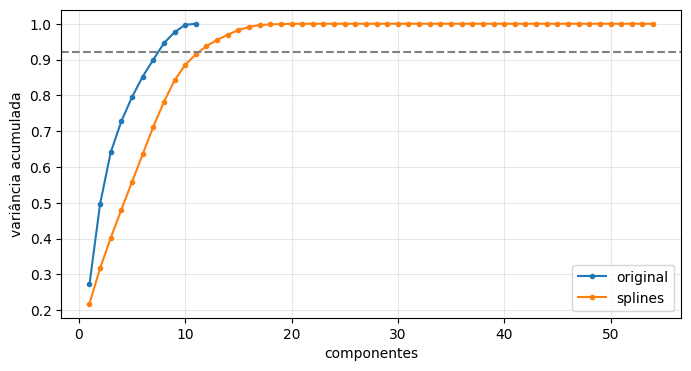

In [28]:
# sem padronizar, total sulfur dioxide (~100) dominaria density (~1)
pca_orig = PCA().fit(StandardScaler().fit_transform(X_orig))
pca_spl = PCA().fit(StandardScaler().fit_transform(X_spl))

var_orig = pd.Series(pca_orig.explained_variance_ratio_, index=range(1, X_orig.shape[1] + 1))
var_spl = pd.Series(pca_spl.explained_variance_ratio_, index=range(1, X_spl.shape[1] + 1))

tab = pd.DataFrame({'original': var_orig, 'orig acum': var_orig.cumsum(),
                    'splines': var_spl, 'spl acum': var_spl.cumsum()})
display(tab.head(20).round(4))

plt.figure(figsize=(8, 4))
plt.plot(var_orig.cumsum(), marker='.', label='original')
plt.plot(var_spl.cumsum(), marker='.', label='splines')
plt.axhline(0.92, color='gray', ls='--')
plt.xlabel('componentes')
plt.ylabel('variância acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Resposta 1: no original a variância fica bem espalhada: o 1º componente explica uns 27%, o 2º uns 22%, e precisa de quase todos pra chegar perto de 100%. Ou seja, as 11 variáveis químicas trazem informação diferente entre si.

Nas splines o 1º componente explica uns 22% e é praticamente só açúcar (residual sugar, ln_sugar_2, ln_sugar_3, ln_sugar_4 com o mesmo peso). A curva chega em 99,9% com uns 20 componentes e depois do 30º a variância é zero, então das 54 colunas só 30 trazem algo novo. O resto é coluna zerada ou combinação de outras.

3- Loop até passar de 0,92

In [29]:
def n_comp(pca, limite=0.92):
    acum = 0
    for n, v in enumerate(pca.explained_variance_ratio_, start=1):
        acum += v
        if acum > limite:
            return n
    # se o limite for 1.0 o acumulado pode parar em 0.9999... por arredondamento
    return len(pca.explained_variance_ratio_)

for nome, pca, X in [('original', pca_orig, X_orig), ('splines', pca_spl, X_spl)]:
    n = n_comp(pca)
    print(f'{nome}: {n} de {X.shape[1]} colunas ({pca.explained_variance_ratio_[:n].sum():.2%} da variância)')

original: 8 de 11 colunas (94.57% da variância)
splines: 12 de 54 colunas (93.76% da variância)


Resposta 3: o original precisa de 8 de 11 componentes, uma redução pequena. As splines precisam de 12 de 54, quase 80% a menos.

Parece que o PCA funciona muito melhor nas splines, mas é porque as 43 colunas novas saíram todas de uma variável só (residual sugar). O PCA está basicamente desfazendo a redundância que a gente mesmo criou.

2- O PCA é bom pras splines? E o ruído?
Pra responder olhamos qual coluna pesa mais em cada componente e quantos vinhos têm valor nela.

In [30]:
linhas = []
for i in range(10):
    pesos = pd.Series(pca_spl.components_[i], index=X_spl.columns).abs().sort_values(ascending=False)
    col = pesos.index[0]
    linhas.append([i + 1, round(var_spl[i + 1], 4), col, (X_spl[col] != 0).sum()])
display(pd.DataFrame(linhas, columns=['comp', 'variância', 'maior peso', 'vinhos com valor']).set_index('comp'))

display(df_spl.loc[df_spl['spl_ln_sugar_2_12'] != 0, ['color', 'residual sugar', 'quality']])

,variância,maior peso,vinhos com valor
comp,,,
1,0.2179,ln_sugar_3,5243
2,0.0992,spl_ln_sugar_2_1,1104
3,0.0846,spl_ln_sugar_2_2,620
4,0.0791,spl_ln_sugar_3_12,1
5,0.0774,spl_ln_sugar_3_4,10
6,0.0770,spl_ln_sugar_4_5,1
7,0.0770,spl_ln_sugar_2_6,1
8,0.0696,spl_ln_sugar_4_0,3309
9,0.0601,density,5320


,color,residual sugar,quality
4391,white,65.8,6


Resposta 2: ajuda em parte, mas não é a melhor escolha.

Ajuda porque as splines têm muita coluna redundante (o mesmo açúcar em várias potências e faixas) e o PCA junta isso em poucos componentes.

Mas tem problemas. O PCA é linear: cada componente é uma soma ponderada das colunas. A spline existe justamente pra modelar uma relação curva entre açúcar e qualidade, e misturando tudo numa combinação linear essa estrutura por faixas se perde e os componentes ficam sem significado. Além disso, as colunas de spline são quase todas zero e só "ligam" numa faixa de açúcar, que não é o tipo de dado em que o PCA vai bem. E o PCA não olha pra quality: ele busca variância, não o que ajuda a prever a nota.

Sobre ruído: o PCA trata qualquer variância como informação, inclusive outlier. A tabela acima mostra isso. O componente 4 (quase 8% da variância) vem das colunas spl_ln_sugar_*_12, que só têm valor pra um vinho (65,8 g/L de açúcar, muito acima do resto). Os componentes 5, 6 e 7 também são colunas com pouquíssimos vinhos. Somando, cerca de 31% da variância é gasta descrevendo uma dúzia de vinhos. Isso acontece porque o StandardScaler deixa toda coluna com desvio 1, então uma coluna com um único valor diferente de zero pesa igual a alcohol.

Obs: o enunciado fala em potências até a 8ª, mas o arquivo vai só até a 4ª. Com potências maiores os valores extremos crescem ainda mais e o problema piora.

4- Método mais indicado
Teste: tirar as colunas zeradas e as que têm valor pra menos de 1% dos vinhos, e rodar o PCA de novo.

In [31]:
X_spl2 = X_spl.loc[:, (X_spl != 0).mean() >= 0.01]  # as zeradas tem 0% de valor != 0, entao saem aqui tambem
pca_spl2 = PCA().fit(StandardScaler().fit_transform(X_spl2))
print(f'{X_spl.shape[1]} -> {X_spl2.shape[1]} colunas')
print('componentes p/ 92%:', n_comp(pca_spl2), '| antes:', n_comp(pca_spl), '| original:', n_comp(pca_orig))

54 -> 27 colunas
componentes p/ 92%: 9 | antes: 12 | original: 8


Resposta 4: não tem uma resposta única, mas aqui faz mais sentido selecionar features antes e, se ainda precisar comprimir, usar Kernel PCA.

Como todas as colunas novas vêm do açúcar, não faz muito sentido "comprimir" colunas que nós mesmos criamos. Só tirando as vazias ou quase vazias o dataset cai pela metade e precisa de 9 componentes pros 92%, um a mais que o original (8). Ou seja, as splines quase não acrescentam informação além do próprio açúcar. Dá pra fazer isso com VarianceThreshold mais um filtro de correlação entre as potências, e as colunas continuam com significado.

Se a ideia for manter a relação não linear que a spline tenta capturar, o Kernel PCA (kernel RBF ou polinomial) consegue achar estruturas curvas que o PCA comum não vê. UMAP e t-SNE servem pra visualizar em 2D, mas não pra gerar features pra modelo (o t-SNE nem transforma dado novo).

Utilize o dataset 'wines.csv'

Uma ideia realmente interessante é a clusterização. Por vezes, podemos nos espantar com certos resultados. Aqui, você deve utilizar o dataset original e separar cada nota em um cluster.

1- Validar os resultados do algoritmo Kmeans com o dataset original

2- Aplicar o método do Cotovelo e averiguar se o número de clusters apontados são iguais ao número de cluster que você tem de usar.

3- Utilizar o método da Silhueta e averiguar se o número de clusters apontados são iguais ao número de cluster que você tem de usar.

4- Explique os principais conceitos dos métodos das questões 2 e 3.

K-Means foi aplicado ao wines.csv sem duplicadas (5.320 vinhos), padronizado, sem color e quality, com random_state=42.



In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,silhouette_score, silhouette_samples)
import seaborn as sns
import numpy as np

In [33]:
Z = StandardScaler().fit_transform(X_orig)

In [34]:
K = df['quality'].nunique()
print('Notas:', sorted(df['quality'].unique()), '-> K =', K)

Notas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] -> K = 7


1. Validar o K-Means com o K = número de notas:

In [35]:
km =KMeans(n_clusters=K, n_init=10, random_state=42).fit(Z)
df_km = df[['quality', 'color']].copy()
df_km['cluster'] = km.labels_

quality,3,4,5,6,7,8,9
cluster,,,,,,,
0,3,24,72,463,368,80,4
1,7,59,396,284,36,2,0
2,5,58,372,432,101,17,0
3,7,23,502,484,63,10,1
4,4,15,170,226,118,13,0
5,3,25,221,425,169,26,0
6,1,2,19,9,1,0,0


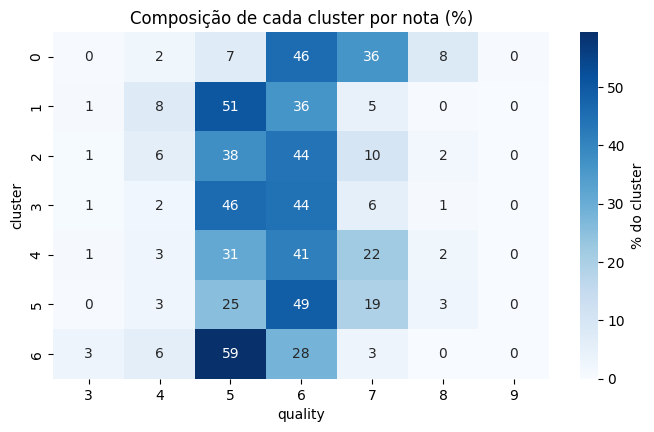

In [36]:
#(a) tabela cluster x nota real
tab = pd.crosstab(df_km['cluster'], df_km['quality'])
display(tab)
#(b) mesma tabela em % da linha (de que notas % é feito cada cluster?)
plt.figure(figsize=(8, 4.5))
sns.heatmap(pd.crosstab(df_km['cluster'], df_km['quality'], normalize='index') * 100,
            annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% do cluster'})
plt.title('Composição de cada cluster por nota (%)');

plt.show()

In [37]:
# (c) métricas: ARI e NMI ignoram a numeração arbitrária dos clusters
print('Clusters vs quality -> ARI:', round(adjusted_rand_score(df_km['quality'], df_km['cluster']), 4),
      '| NMI:', round(normalized_mutual_info_score(df_km['quality'], df_km['cluster']), 4))

Clusters vs quality -> ARI: 0.0358 | NMI: 0.0655


In [38]:
# (d) os clusters estão separando outra coisa? comparando com a cor do vinho
print('Clusters vs color   -> ARI:', round(adjusted_rand_score(df_km['color'], df_km['cluster']), 4),
      '| NMI:', round(normalized_mutual_info_score(df_km['color'], df_km['cluster']), 4))
display(pd.crosstab(df_km['cluster'], df_km['color']))

Clusters vs color   -> ARI: 0.2039 | NMI: 0.3998


color,red,white
cluster,,
0,27,987
1,747,37
2,9,976
3,3,1087
4,531,15
5,16,853
6,26,6


Resposta 1: o K-Means com K = 7 (uma nota por cluster) não conseguiu reproduzir as notas. O ARI contra quality é 0,036 e o NMI é 0,066, os dois muito perto de 0, o que nos leva a concluir que, o agrupamento é praticamente tão bom quanto um sorteio.

A tabela cluster × nota confirma. Todos os clusters misturam várias notas, e as notas 5 e 6 aparecem em quase todos eles. Elas concentram 77% dos vinhos (4.075 de 5.320), enquanto as notas 3 e 9 têm só 30 e 5 vinhos. Se atribuirmos a cada cluster a nota mais frequente nele, acertamos 46,3% dos vinhos, pouco acima dos 43,7% de simplesmente chutar a nota 6 para todos. Os clusters 1 e 6 pendem para a nota 5 (51% e 59%) e o cluster 0 vai para notas altas (44% de notas 7 e 8), mas mesmo esses têm mistura grande, e o cluster 6 tem só 32 vinhos.

Os clusters se alinham muito mais com a cor do que com a nota. O ARI contra color é 0,204 e o NMI é 0,400. O ARI de 0,20 parece baixo porque comparamos 7 clusters com apenas 2 classes (os brancos foram divididos em 4 clusters), mas a tabela cluster × cor mostra que quase todos os clusters são puros: os clusters 1 e 4 são ~95% tintos, e os clusters 0, 2, 3 e 5 são mais de 97% brancos. No total, 97,9% dos vinhos estão em um cluster em que a cor deles é a maioria.

Isso explica o resultado do enunciado. As 11 medidas químicas separam bem tinto de branco, que é a estrutura mais forte dos dados, mas não bastam para separar as notas, que são dadas por provadores e se sobrepõem muito.

 2. Método do Cotovelo

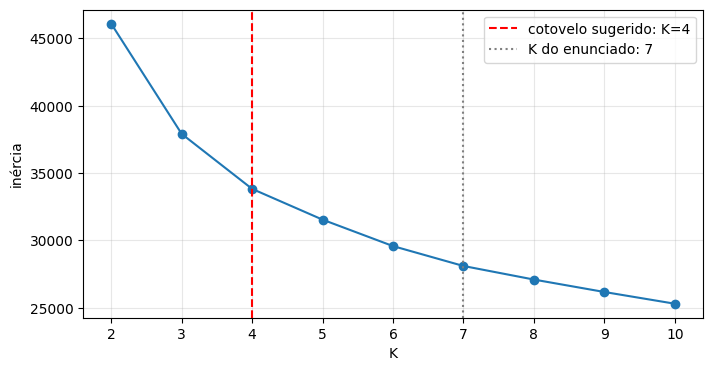

,inércia,queda vs K anterior
2,46095.4,NaN
3,37914.9,-8180.6
4,33828.6,-4086.3
5,31544.3,-2284.3
6,29580.4,-1963.9
7,28102.7,-1477.6
8,27094.8,-1007.9
9,26171.1,-923.6
10,25300.6,-870.5


Cotovelo sugerido: 4 | K do enunciado: 7 | iguais? False


In [39]:
ks = range(2, 11)
inercia = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z).inertia_ for k in ks]

x = np.array(list(ks), dtype=float); y = np.array(inercia)
xn, yn = (x - x.min()) / (x.max() - x.min()), (y - y.min()) / (y.max() - y.min())
dist = np.abs(xn + yn - 1) / np.sqrt(2)
k_cotovelo = int(x[dist.argmax()])

plt.figure(figsize=(8, 4))
plt.plot(list(ks), inercia, marker='o')
plt.axvline(k_cotovelo, color='red', ls='--', label=f'cotovelo sugerido: K={k_cotovelo}')
plt.axvline(K, color='gray', ls=':', label=f'K do enunciado: {K}')
plt.xlabel('K'); plt.ylabel('inércia'); plt.legend(); plt.grid(alpha=.3); plt.show()

tab_in = pd.DataFrame({'inércia': inercia}, index=list(ks))
tab_in['queda vs K anterior'] = tab_in['inércia'].diff()
display(tab_in.round(1))
print('Cotovelo sugerido:', k_cotovelo, '| K do enunciado:', K, '| iguais?', k_cotovelo == K)

Resposta 2: o método do Cotovelo não aponta o mesmo número de clusters que o enunciado pede. O critério geométrico indicou K = 4, e o enunciado exige K = 7 (uma nota por cluster).

A inércia cai de forma contínua. A maior queda é de K = 2 para K = 3 (−8.181), e depois ela cai pela metade em cada passo: −4.086 de 3 para 4 e −2.284 de 4 para 5. A partir daí a curva fica quase reta, com quedas pequenas e parecidas. A dobra está, portanto, na região de K = 3 a 5, e K = 4 é o ponto em que o ganho de acrescentar mais um cluster deixa de ser grande. Essa dobra é suave, sem um "joelho" bem marcado, então a escolha de K = 4 é um critério e não uma certeza.

O K = 7 já está na parte achatada da curva. Passar de 4 para 7 clusters reduz a inércia em cerca de 5.726, enquanto só o passo de 2 para 3 reduzia 8.181, O que nos faz pensar que separar os vinhos em 7 grupos não é justificado pela estrutura dos dados medida pela inércia, o que é coerente com o item 1: as notas não formam grupos naturais nas 11 variáveis.

3. Método da silhueta

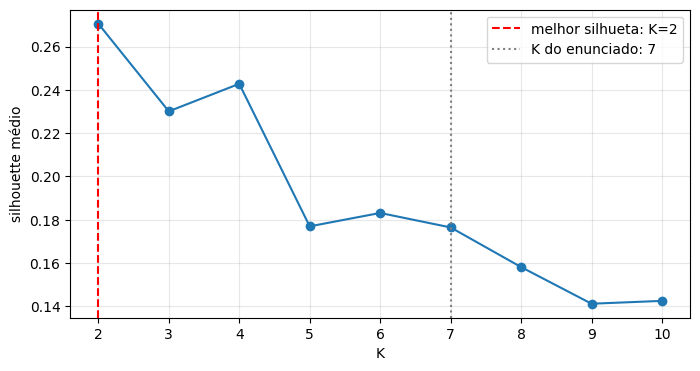

,2,3,4,5,6,7,8,9,10
silhouette,0.2705,0.2301,0.2428,0.1769,0.1831,0.1764,0.1581,0.1412,0.1425


Melhor K pela silhueta: 2 | K do enunciado: 7 | iguais? False
Silhueta com K=7: 0.1764


In [40]:
sil = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Z))
       for k in range(2, 11)}
k_sil = max(sil, key=sil.get)

plt.figure(figsize=(8, 4))
plt.plot(list(sil), list(sil.values()), marker='o')
plt.axvline(k_sil, color='red', ls='--', label=f'melhor silhueta: K={k_sil}')
plt.axvline(K, color='gray', ls=':', label=f'K do enunciado: {K}')
plt.xlabel('K'); plt.ylabel('silhouette médio'); plt.legend(); plt.grid(alpha=.3); plt.show()

display(pd.Series(sil, name='silhouette').round(4).to_frame().T)
print('Melhor K pela silhueta:', k_sil, '| K do enunciado:', K, '| iguais?', k_sil == K)
print(f'Silhueta com K={K}: {sil[K]:.4f}')

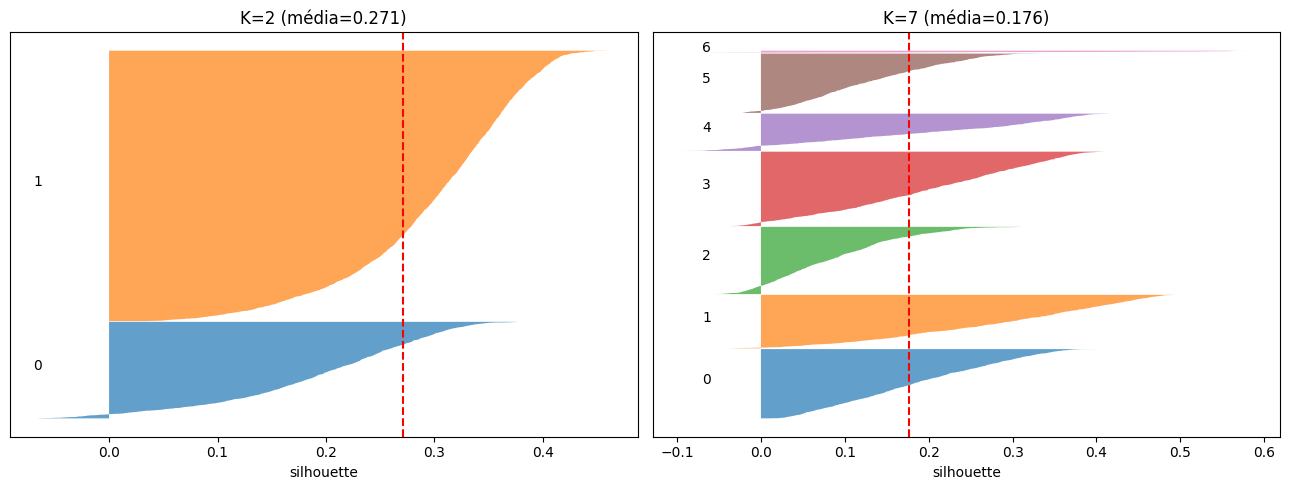

% de pontos com silhueta negativa (K do enunciado): 5.7


In [41]:
#Silhueta por ponto, com K do enunciado e com o K ótimo: mostra clusters fracos e pontos mal alocados
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, k in zip(axes, sorted({K, k_sil})):
    lab = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Z)
    s = silhouette_samples(Z, lab); y0 = 10
    for c in range(k):
        sc = np.sort(s[lab == c]); ax.fill_betweenx(np.arange(y0, y0 + len(sc)), 0, sc, alpha=.7)
        ax.text(-0.07, y0 + len(sc) / 2, str(c)); y0 += len(sc) + 10
    ax.axvline(s.mean(), color='red', ls='--'); ax.set_title(f'K={k} (média={s.mean():.3f})')
    ax.set_xlabel('silhouette'); ax.set_yticks([])
plt.tight_layout(); plt.show()
print('% de pontos com silhueta negativa (K do enunciado):',
      round((silhouette_samples(Z, KMeans(n_clusters=K, n_init=10, random_state=42).fit_predict(Z)) < 0).mean() * 100, 1))

In [42]:
#verificação extra: K=2 coincide com a cor?.
verificação = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Z)
print(adjusted_rand_score(df_km['color'], verificação))
display(pd.crosstab(lab2, df_km['color']))

0.9335365661793259


color,red,white
row_0,,
0,1337,63
1,22,3898


Resposta 3: o método da Silhueta também não aponta o K do enunciado. A maior silhueta média é a de K = 2 (0,2705), e a de K = 7 é 0,1764, que está entre as mais baixas da faixa testada (só K = 8, 9 e 10 ficam abaixo, com 0,1581, 0,1412 e 0,1425). Os dois métodos divergem entre si e do enunciado: o cotovelo sugeriu 4, a silhueta sugere 2 e o enunciado exige 7.

A curva cai quase continuamente com K. Há um pico local em K = 4 (0,2428, acima de K = 3, com 0,2301), que coincide com o K sugerido pelo cotovelo, e depois uma queda forte para K = 5 (0,1769). Isso sugere que, se houver alguma estrutura além do K = 2, ela está em torno de 4 grupos, e não de 7.

Os valores absolutos também são baixos. Pela regra prática de interpretação, silhuetas abaixo de ~0,25 indicam estrutura fraca, com K = 7 a silhueta média é 0,176, com 5,7% dos vinhos com silhueta negativa, ou seja, provavelmente no cluster errado. Mesmo o melhor valor (0,27) fica apenas um pouco acima desse limite, então a estrutura em dois grupos é moderada, não forte.

No gráfico por ponto, os clusters de K = 7 têm silhuetas baixas e de larguras parecidas, sem nenhum claramente separado dos demais, enquanto com K = 2 os dois clusters são bem mais coerentes, mesmo que o  menor ainda tenha uma cauda de pontos negativos.

Com K = 2, os dois clusters coincidem quase perfeitamente com a cor do vinho: o ARI contra color é 0,934 (contra 0,204 com K = 7). O cluster 0 tem 1.337 tintos e 63 brancos, e o cluster 1 tem 22 tintos e 3.898 brancos, ou seja, 98,4% dos vinhos ficam no cluster da sua cor (apenas 85 de 5.320 trocados). A melhor silhueta, portanto, está justamente na separação tinto × branco, a estrutura mais forte dos dados, e não na nota.

Conclusão: os dados têm uma separação principal em dois grupos e pouca estrutura além disso. Dividir em 7 clusters (um por nota) não é sustentado pela silhueta, o que reforça o resultado do item 1.

Resposta 4:

**Método do Cotovelo**: Roda o K-Means para vários valores de K e calcula a inércia de cada um: a soma das distâncias ao quadrado entre cada ponto e o centro do seu cluster.
O que é procurar o "cotovelo"?
 o ponto a partir do qual acrescentar mais um cluster traz ganhos cada vez menores e a curva no gráfico passa de uma queda forte para uma queda lenta.

**Método da Silhueta**: Mede a qualidade do agrupamento olhando, para cada ponto, a coesão e a separação. Seja a a distância média do ponto aos demais pontos do seu próprio cluster e b a distância média dele aos pontos do cluster vizinho mais próximo.** A silhueta do ponto é s = (b − a) / max(a, b), e vai de −1 a 1**.
 Em relação ao cotovelo, tem a vantagem de dar um critério numérico, mas tem custo computacional maior, pois compara todos os pares de pontos e favorece clusters compactos e de tamanho parecido, como os que o próprio K-Means produz.

No nosso caso: os dois métodos deram respostas diferentes (cotovelo: K = 4; silhueta: K = 2), e nenhum coincidiu com o K = 7 do enunciado. Isso mostra a diferença entre eles: o cotovelo mede só a compactação dos clusters e aponta onde o ganho diminui, enquanto a silhueta mede também o quanto os clusters estão separados uns dos outros.

Utilize o dataset 'logs_firewall.xlsx'

A Università di Bologna tem cursos de graduação e pós graduação em enologia. Os grandes enólogos do mundo são os únicos que podem fazer o doutorado nesta renomada universidade. Esta instituição tem um contrato milionário com o Sr.Donald, onde todos os alunos poderiam comparecer uma semana a cada três meses para estudar as características, mecânicas de plantações, tecnologias, processos de confecção dos vinhos, entre outras matérias. Todos os professores, escanções extremamente bem conceituados, sempre estão presentes.

Caso infortúnio, O Sr.Hafþór Júlíus Björnsson, mais conhecido como "o Montanha", chefe de segurança cibernética da empresa apertou o botão DEFCON-1 ao perceber que os servidores tinham sido 'hackeados'. Momento em que notou que os bancos de dados que continham as notas dos vinhos haviam sido alterados/deletados e o backup infectado por um Ransomware chamado "HUE HUE HUE BR". Aparentemente, os black-hats conseguiram alterar de 5% a 25% dos dados referentes aos vinhos tintos, antes que o Montanha conseguisse exterminar as conexões dos servidores.

O Sr.Donald Shelby aproximou-se para falar com você sobre as políticas da empresa, criadas por sua esposa, que dispunham sobre o bem estar, ambiente não tóxico, agregação dos "colaboradores" ~pseudo escravos~ como familiares, dentre outros ideais da mesma seara. Em seguida incorporou o espírito de Don Corleone e proferiu uma de suas máximas ao falar "Política é saber a hora de puxar o gatilho".

Uma regra clara da empresa dispõe sobre a impossibilidade de extrair datasets como arquivos e, toda vez que for utilizar os dados no Jupyter Notebook, deve ser realizado uma query no datalake. Ocorre que, 'sem querer querendo', você estava "desatento" e salvou os dados para estudos quando estivesse em casa. Nítido que se disse-se que havia copiado quaisquer dados seria torturado, por isso não poderia simplesmente colocá-los de volta no banco e, como não queria morrer, tinha de encontrar vias oblíquas para dirimir a questão.

Erick Cartman, analista de infraestrutura, recebeu ordens para recuperar os dados a qualquer custo e, caso falhasse, seria devidamente penalizado ~executado~. Desolado, regado a fanta uva, com palavras arrastadas e chiadas, Erick lhe pediu ajuda. Com muita pena, pegou seu disquete que continha a cópia dos dados e o entregou, pedindo extrema confidencialidade.

Para sua surpresa, após ter a vida salva, receber aumentos salariais e bonificações, Erick te chantageou. "Agora pediram para eu analisar os logs do firewall que contém informações de acesso a servidores e descobrir os possíveis culpados. Eu não sei fazer isso não, 'ocê tá LOUKO'. Dá teus pulos aí se não eu te conto que você copia dados da empresa!!!"

Conhecedor de diversas técnicas para detecção de outliers, se lembrou de uma que já tinha experiência: Isolation Forest.

1- Descubra o nome do responsável pelo o ataque.

ps: Recentemente houve um estudo estatístico que comprovou que existe um fator de risco em relação aos horários de acesso, são eles:

Entre 09:00 às 12:00 o risco varia entre 0-10%

Entre 12:00 às 14:00 o risco varia entre 5-10%

Entre 14:00 às 19:00 o risco varia entre 0-10%

Entre 19:00 às 21:00 o risco varia entre 20-30%

Entre 21:00 às 23:00 o risco varia entre 40-50%

Entre 00:00 às 02:00 o risco varia entre 60-80%

Entre 02:00 às 06:00 o risco varia entre 80-100%

Entre 06:00 às 09:00 o risco varia entre 30-40%